In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
from scipy.optimize import *

from scipy import interpolate

## My Code

In [3]:
def Schechter(S, params):
    alpha, S0, N0 = params
    return (N0 * 3600/ S0) * (S/S0)**alpha * np.exp(-S/S0)

In [4]:
def DoublePowerLaw(S, params):
    alpha, beta, S0, N0 = params
    return (N0* 3600/S0) * ((S/S0)**alpha + (S/S0)**beta)**-1

In [5]:
def log_residual(params, func, x, y):
    # pass params as a single array (do NOT unpack)
    model = np.array([func(params, xi) for xi in x])
    mask = (model > 0) & (y > 0)
    return np.log10(model[mask]) - np.log10(y[mask])

In [6]:
def log_residual_asym(params, model, x, y, yerr_lower, yerr_upper):
    y_model = model(x, params)  # now order matches
    residuals = np.log10(y) - np.log10(y_model)
    
    sigma = np.where(y_model > y, yerr_upper, yerr_lower)
    sigma_log = sigma / (y * np.log(10))
    
    return residuals / sigma_log

In [7]:
df_cumulative_Chen = pd.DataFrame({
    "S" : np.array([0.19, 0.32, 0.52, 0.86, 1.43, 2.36, 3.91, 6.47]),
    "N"    : np.array([92, 84, 69, 53, 39, 25, 13, 4]),
    "dN/dS": [21900, 12950, 7390, 4120, 2660, 1540, 770, 230],
    "dN/dS err lower": [3250, 1640, 930, 560, 420, 300, 210, 110], 
    "dN/dS err upper": [3250, 1640, 930, 560, 420, 370, 270, 180]
})

df_cumulative_Chen[""] = ["|" for S in df_cumulative_Chen["S"]]


df_cumulative_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper,
0,0.19,92,21900,3250,3250,|
1,0.32,84,12950,1640,1640,|
2,0.52,69,7390,930,930,|
3,0.86,53,4120,560,560,|
4,1.43,39,2660,420,420,|
5,2.36,25,1540,300,370,|
6,3.91,13,770,210,270,|
7,6.47,4,230,110,180,|


In [8]:
df_diff_Chen = pd.DataFrame({
    "S": [0.25, 0.42, 0.69, 1.15, 1.90, 3.14, 5.19],
    "N": np.array([8, 15, 16, 14, 14, 12, 9]),
    "dN/dS": [73860, 28600,  10230,  2780, 1280, 530, 220], # Units of mJy^-1 deg^-2
    "dN/dS err lower": [29940, 8210, 2670, 740, 340, 150, 70], 
    "dN/dS err upper": [39660, 10180, 3350, 960, 440, 200, 100]
})


df_diff_Chen[""] = ["|" for S in df_diff_Chen["S"]]


df_diff_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper,
0,0.25,8,73860,29940,39660,|
1,0.42,15,28600,8210,10180,|
2,0.69,16,10230,2670,3350,|
3,1.15,14,2780,740,960,|
4,1.90,14,1280,340,440,|
5,3.14,12,530,150,200,|
6,5.19,9,220,70,100,|


In [9]:
# 3600/1000

2.2/3.6

0.6111111111111112

In [10]:
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # Differential Schechter (alpha, S0, N0)

Schechter_Diferential_Guess = [-1.7, 3.9, 2.2/3.6]

# Differential DPL (alpha, beta, S0, N0)
DoublePowerLaw_Diferential_Guess = [2.0, 4.7, 5.6, 0.8/3.6]

# Cumulative Schechter (alpha, S0, N0)
Schechter_Cumulative_Guess = [-0.6, 2.2, 9.6/3.6]

# Cumulative DPL (alpha, beta, S0, N0)
DoublePowerLaw_Cumulative_Guess = [1.0, 4.7, 4.5, 3.6/3.6]

In [11]:
# --- Differential Schechter ---
results1 = least_squares(
    log_residual_asym,
    Schechter_Diferential_Guess,
    args=(Schechter, df_diff_Chen["S"], df_diff_Chen["dN/dS"],
          df_diff_Chen["dN/dS err lower"], df_diff_Chen["dN/dS err upper"])
)

# --- Differential Double Power Law ---
results2 = least_squares(
    log_residual_asym,
    DoublePowerLaw_Diferential_Guess,
    args=(DoublePowerLaw, df_diff_Chen["S"], df_diff_Chen["dN/dS"],
          df_diff_Chen["dN/dS err lower"], df_diff_Chen["dN/dS err upper"]),
    bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf])
)

# --- Cumulative Schechter ---
results3 = least_squares(
    log_residual_asym,
    Schechter_Cumulative_Guess,
    args=(Schechter, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"],
          df_cumulative_Chen["dN/dS err lower"], df_cumulative_Chen["dN/dS err upper"])
)



# --- Cumulative Double Power Law ---
results4 = least_squares(
    log_residual_asym,
    DoublePowerLaw_Cumulative_Guess,
    args=(DoublePowerLaw, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"],
          df_cumulative_Chen["dN/dS err lower"], df_cumulative_Chen["dN/dS err upper"]),
    bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf])
)


/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
S_grid = np.linspace(0.05, 30, 1000)

# Evaluate best-fit models
schechter_fit_diff = Schechter(S_grid, results1.x) * S_grid**2.5
dpl_fit_diff       = DoublePowerLaw(S_grid, results2.x) * S_grid**2.5

schechter_fit_diff_paper = Schechter(S_grid, Schechter_Diferential_Guess) * S_grid**2.5

# Evaluate best-fit models
schechter_fit_cumulative = Schechter(S_grid, results3.x)


# schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 


schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 

dpl_fit_cumulative       = DoublePowerLaw(S_grid, results4.x) 

In [13]:
# Print resilts
print("\n===== FIT RESULTS =====")


print("Differential Schechter: alpha = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results1.x))
print(" ")

print("Differential DPL:       alpha = %.3f, beta = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results2.x))
print(" ")

print("Cumulative Schechter:   alpha = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results3.x))
print(" ")

print("Cumulative DPL:         alpha = %.3f, beta = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results4.x))
print(" ")


===== FIT RESULTS =====
Differential Schechter: alpha = -1.946, S0 = 1.18e+04, N0 = 0.000189
 
Differential DPL:       alpha = 1.946, beta = 16.400, S0 = 17, N0 = 0.092
 
Cumulative Schechter:   alpha = -1.008, S0 = 12.1, N0 = 1.12
 
Cumulative DPL:         alpha = 1.064, beta = 5.889, S0 = 6.19, N0 = 0.925
 


In [14]:
# Compute the lower and upper errors on the y-values
yerr_lower_diff = df_diff_Chen["dN/dS err lower"] * df_diff_Chen["S"]**2.5
yerr_upper_diff = df_diff_Chen["dN/dS err upper"] * df_diff_Chen["S"]**2.5

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_diff = np.array([yerr_lower_diff, yerr_upper_diff])

In [15]:
# Compute the lower and upper errors on the y-values
yerr_lower_cumulative = df_cumulative_Chen["dN/dS err lower"]
yerr_upper_cumulative = df_cumulative_Chen["dN/dS err upper"]

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_cumulative = np.array([yerr_lower_cumulative, yerr_upper_cumulative])

## Paper Code

In [16]:
from astropy.table import Table

In [17]:
def schechter(s, a=0, S0=1, N0=1):
    return N0*3600/S0*(s/S0)**(a+1)*np.exp(-s/S0)

In [18]:
def flux_scaling(wavelength, target_wavelength, flux=1, SED_template='data/uds_composite_sed_Lir_ld.dat', z=2.0,
                 debug=False):
    """interpolate the flux at a specified wavelength
    
    Params:
        wavelength : in um
        flux : any units, self consistent
    """
    SED = np.loadtxt(SED_template)
    f_SED = interpolate.interp1d(SED[:,0]*(1.0+z), SED[:,1]/(1+z)**4)
    scale_factor = flux / f_SED(wavelength)
    if debug:
        print("flux at {}: {}".format(wavelength, f_SED(wavelength)))
        print("flux at {}: {}".format(target_wavelength, f_SED(target_wavelength)))
        print("scale_factor: {}".format(scale_factor))
        print("flux difference: {}".format(f_SED(wavelength)/f_SED(target_wavelength)))
    return scale_factor * f_SED(target_wavelength)

In [19]:
S_alma_scale = {}
S_alma = {'B3': 3027.9403678720932, 'B4': 2085.4643523587724, 'B5': 1595.2429758332012, 'B6': 1259.8894674554122, 
          'B7': 886.746475901551, 'B8': 673.4616464220171, 'B9': 444.86026069217337, 'B10': 341.799906987015}
S_ref = {'B3': 3000., 'B4': 2000., 'B5': 1500., 'B6': 1200., 'B7': 870., 'B8': 650., 'B9': 440., 'B10': 340.}
for band in ['B3','B4','B5','B6','B7','B8','B9','B10']:
    S_alma_scale[band] = flux_scaling(S_alma[band], S_ref[band], z=2.0)
print(S_alma_scale)

{'B3': 1.0382580304780473, 'B4': 1.1999533136892222, 'B5': 1.2966567022995046, 'B6': 1.2177778304099698, 'B7': 1.0733908077711678, 'B8': 1.1238182849239595, 'B9': 1.0292754797521029, 'B10': 1.0000000000000004}


In [20]:
S_almacal_B7toS870 = 1.07

## Plot

(0.1, 100000)

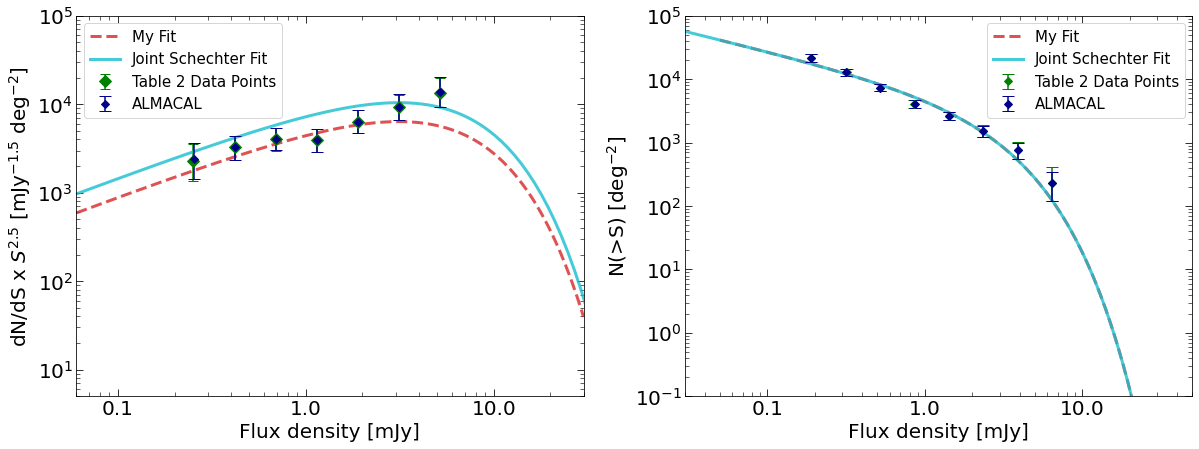

In [21]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# Set colors 
# ---------------------------------------------
my_line_color = 'tab:red'
chen_line_color = 'tab:cyan'

my_data_point_color = 'green'
chen_data_point_color = 'darkblue'
# ---------------------------------------------

# Left Plot Data
# ------------------------------------------------------------------------------------
# My data
ax[0].errorbar(
    df_diff_Chen["S"],
    df_diff_Chen["dN/dS"] * df_diff_Chen["S"]**2.5,
    yerr=yerr_diff,
    fmt='D',             # diamond marker
    color=my_data_point_color,
    markersize=8,
    capsize=5,           # little horizontal bar at the ends
    elinewidth=1.5,
    label ='Table 2 Data Points'
)

ax[0].plot(S_grid, schechter_fit_diff_paper, color=my_line_color, alpha = 0.8, ls = '--',  lw=3, label='My Fit')

# ax[0].plot(, color=chen_line_color, alpha = 0.8,  lw=3, label='Paper Code')

# ------------------------------------------------------------------------------------
# Paper Data
B7_x_fitted = np.logspace(-2, 1.5, 100)
yf = B7_x_fitted**2.5
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. the alpha definite is a bit different here, see the schechter function in the beginning
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1, S0, N0], N0 here in mJy/arcmin2
ax[0].plot(B7_x_fitted, 
        yf*schechter(B7_x_fitted, *B7_schechter_diffsols[:-1]), 
        color='tab:cyan', 
        linewidth=3, 
        alpha=0.8, 
        label='Joint Schechter Fit')



# Read ALMACAL number counts
almacal_B7 = Table.read('data/B7_bus-False_diff.txt', format='ascii')

yf = (almacal_B7['flist']*S_alma_scale['B7'])**2.5

ax[0].errorbar(almacal_B7['flist']*S_alma_scale['B7'], 
            yf*almacal_B7['dN'], 
            yerr=[yf*almacal_B7['dNerr_lower'], 
                  yf*almacal_B7['dNerr_upper']], 
            label='ALMACAL', 
            markersize=6, 
            marker='D', 
            capsize=6.0, 
            linestyle="none", 
            color='darkblue')
# ------------------------------------------------------------------------------------


# Right Plot Data
# ------------------------------------------------------------------------------------
# My data
ax[1].errorbar(
    df_cumulative_Chen["S"],
    df_cumulative_Chen["dN/dS"],
    yerr=yerr_cumulative,
    fmt='D',             # diamond marker
    color=my_data_point_color,
    markersize=6,
    capsize=6,           # little horizontal bar at the ends
    elinewidth=1.5,
    label ='Table 2 Data Points'
)

ax[1].plot(S_grid, schechter_fit_cumulative_paper, color=my_line_color, alpha = 0.8, ls = '--', lw=3, label='My Fit')
# ------------------------------------------------------------------------------------
B7_flux_fitted = np.logspace(-2, 1.5, 100)
# plot the best fitting
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. 
# The alpha definite is a bit different here as the paper, see the schechter function in the beginning
B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1, S0, N0]

ax[1].plot(B7_flux_fitted, 
        schechter(B7_flux_fitted, *B7_schechter_sols), 
        linewidth=3., 
        alpha=0.8, 
        color='tab:cyan', 
        label='Joint Schechter Fit')

almacal_B7 = Table.read('data/B7_bus-False.txt', format='ascii')
#almacal_B7 = Table.read('tests/B7_number_counts_v5.1_py3.txt', format='ascii')
ax[1].errorbar(almacal_B7['flist']*S_almacal_B7toS870, almacal_B7['N'], yerr=almacal_B7['Nerr_lower'], label='ALMACAL',
            markersize=6, marker='D', capsize=6.0, linestyle="none", color='darkblue')
# ------------------------------------------------------------------------------------




# Set y-axis labels 
# ----------------------------------------------------------------------------------------------
ax[0].set_ylabel('dN/dS x $S^{2.5}$ [mJy$^{-1.5}$ deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)
# ----------------------------------------------------------------------------------------------

# Add an x-label, proper ticks on axes and add a legend
# ----------------------------------------------------------------------------------------------
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)

    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")
# ----------------------------------------------------------------------------------------------
    
# Set the bounds
# ------------------------------------------
# Bounds of left plot from the paper code
ax[0].set_xlim(0.06, 30)
ax[0].set_ylim(5., 1e5)
# ------------------------------------------
# Bounds of right plot from the paper code
ax[1].set_xlim(0.03, 50)
ax[1].set_ylim(0.1, 10**5)
# ------------------------------------------